In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


IMPORTING DATASETS

In [ ]:
import os
path = "/content/drive/MyDrive/"
os.path.exists(path)

True

COMBINNING DATASET WITH SCENERIO FD00(1-4)

In [ ]:
import pandas as pd
import numpy as np

op_settings = ['op_setting_1', 'op_setting_2', 'op_setting_3']
sensors = [f'sensor_{i}' for i in range(1, 22)]
cols = ['unit_number', 'time_in_cycles'] + op_settings + sensors
data_path = "/content/drive/MyDrive/C-MAPPS/archive/"

all_train_data = []
last_unit = 0
print("Processing training data...")
scen_files = ['FD001', 'FD002', 'FD003', 'FD004']

for file_name in scen_files:
    df = pd.read_csv(f'{data_path}train_{file_name}.txt', sep='\s+', header=None, names=cols, engine = 'python')

    df['global_unit_number'] = df['unit_number'] + last_unit
    max_cycles = df.groupby('global_unit_number')['time_in_cycles'].max().reset_index()
    max_cycles.columns = ['global_unit_number', 'max_cycles']

    df = pd.merge(df, max_cycles, on='global_unit_number', how='left')
    df['RUL'] = df['max_cycles'] - df['time_in_cycles']
    df.drop(columns=['max_cycles'], inplace=True)

    all_train_data.append(df)
    last_unit = df['global_unit_number'].max()

    print(f"Processed {file_name}: {df['global_unit_number'].nunique()} engines, last global ID = {last_unit}")
train_df = pd.concat(all_train_data, axis=0)
train_df.reset_index(drop=True, inplace=True)

print("\n--- Data Processing Complete ---")
print(f"Total number of rows: {train_df.shape[0]}")
print(f"Total number of unique engines: {train_df['global_unit_number'].nunique()}")

print("\nSample of the final combined training data:")
display_cols = ['global_unit_number', 'unit_number', 'time_in_cycles', 'sensor_2', 'sensor_3', 'RUL']
print(train_df[display_cols].head())
print("\nTail of the dataframe showing RUL calculation:")
print(train_df[display_cols].tail())

<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:15: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-3573471183.py:15: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(f'{data_path}train_{file_name}.txt', sep='\s+', header=None, names=cols, engine = 'python')


Processing training data...
Processed FD001: 100 engines, last global ID = 100
Processed FD002: 260 engines, last global ID = 360
Processed FD003: 100 engines, last global ID = 460
Processed FD004: 249 engines, last global ID = 709

--- Data Processing Complete ---
Total number of rows: 160359
Total number of unique engines: 709

Sample of the final combined training data:
   global_unit_number  unit_number  time_in_cycles  sensor_2  sensor_3  RUL
0                   1            1               1    641.82   1589.70  191
1                   1            1               2    642.15   1591.82  190
2                   1            1               3    642.35   1587.99  189
3                   1            1               4    642.35   1582.79  188
4                   1            1               5    642.37   1582.85  187

Tail of the dataframe showing RUL calculation:
        global_unit_number  unit_number  time_in_cycles  sensor_2  sensor_3  \
160354                 709          249  

In [ ]:
d = train_df['global_unit_number'].value_counts()
print(f"Count for unit number 1: {d.get(1, 'Not found')}")

Count for unit number 1: 192


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

all_test_data = []
all_targets_data = []
last_unit_test = 0

print("Processing test and RUL data...")
for file_num in range(1, 5):
    file_name = f'FD00{file_num}'

    df_test = pd.read_csv(f'{data_path}test_{file_name}.txt', sep='\s+', header=None, names=cols, engine = 'python')
    df_rul = pd.read_csv(f'{data_path}RUL_{file_name}.txt', sep='\s+', header=None, names=['RUL'] , engine = 'python')

    df_test['global_unit_number'] = df_test['unit_number'] + last_unit_test

    all_test_data.append(df_test)
    all_targets_data.append(df_rul)
    last_unit_test = df_test['global_unit_number'].max()

    print(f"Processed {file_name}: {df_test['global_unit_number'].nunique()} engines, last global ID = {last_unit_test}")

X_test = pd.concat(all_test_data)
target_df = pd.concat(all_targets_data)
target_df.reset_index(drop = True, inplace = True)

X_test = X_test.reset_index(drop = True)

print("\n--- All Test and Target Data Combined ---")
print(f"Shape of final combined test features: {X_test.shape}")
print(f"Shape of final combined RUL targets: {target_df.shape}")

<>:12: SyntaxWarning: invalid escape sequence '\s'
<>:13: SyntaxWarning: invalid escape sequence '\s'
<>:12: SyntaxWarning: invalid escape sequence '\s'
<>:13: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-547638235.py:12: SyntaxWarning: invalid escape sequence '\s'
  df_test = pd.read_csv(f'{data_path}test_{file_name}.txt', sep='\s+', header=None, names=cols, engine = 'python')
/tmp/ipython-input-547638235.py:13: SyntaxWarning: invalid escape sequence '\s'
  df_rul = pd.read_csv(f'{data_path}RUL_{file_name}.txt', sep='\s+', header=None, names=['RUL'] , engine = 'python')


Processing test and RUL data...
Processed FD001: 100 engines, last global ID = 100
Processed FD002: 259 engines, last global ID = 359
Processed FD003: 100 engines, last global ID = 459
Processed FD004: 248 engines, last global ID = 707

--- All Test and Target Data Combined ---
Shape of final combined test features: (104897, 27)
Shape of final combined RUL targets: (707, 1)


Transformning the train dataset to match the final X_train shape, removing 10 last rows from each unique engine.

In [ ]:
def transforming_y(data):
  filtered_engines = []
  for engine_id, engine_data in data.groupby('global_unit_number'):
    filtered_engine = engine_data.iloc[:-10]
    filtered_engines.append(filtered_engine)

  filtered_df = pd.concat(filtered_engines).reset_index(drop = True)
  y_filtered = filtered_df[['global_unit_number','RUL']]
  print(type(y_filtered))
  return y_filtered

In [ ]:
y_filtered = transforming_y(train_df)
y_filtered_clipped = y_filtered.copy()
max_rul = 125
y_filtered_clipped['RUL'] = y_filtered_clipped['RUL'].clip(upper = max_rul)
y_filtered.shape, y_filtered_clipped.shape, y_filtered_clipped['RUL'].max()

<class 'pandas.core.frame.DataFrame'>


((153269, 2), (153269, 2), 125)

In [ ]:
import numpy as np
all_engine_ids = train_df['global_unit_number'].unique()
val_size = 0.2
num_of_val_engines = int(len(all_engine_ids)*val_size)
rng = np.random.default_rng(42)
rng.shuffle(all_engine_ids)
val_engine_ids = all_engine_ids[:num_of_val_engines]
train_engine_ids = all_engine_ids[num_of_val_engines:]
print(len(all_engine_ids))
print(len(val_engine_ids))
print(len(train_engine_ids))
print(num_of_val_engines)

709
141
568
141


Splitting the training dataset into 80 percent engines as train and 20 percent engines as validation

In [ ]:
features = ['op_setting_1', 'op_setting_2', 'op_setting_3'] + [f'sensor_{i}' for i in range(1, 22)]
columns = ['global_unit_number', 'op_setting_1', 'op_setting_2', 'op_setting_3'] + [f'sensor_{i}' for i in range(1, 22)]
X_train = train_df[train_df["global_unit_number"].isin(train_engine_ids)]
X_val = train_df[train_df['global_unit_number'].isin(val_engine_ids)]
y_train = y_filtered_clipped[y_filtered_clipped['global_unit_number'].isin(train_engine_ids)].drop('global_unit_number', axis = 1)[5:]
y_val = y_filtered[y_filtered['global_unit_number'].isin(val_engine_ids)].drop('global_unit_number', axis = 1)[5:]

In [ ]:
y_val.shape, y_filtered_clipped.shape, y_train.shape

((31289, 1), (153269, 2), (121970, 1))

In [ ]:
len(columns)

25

In [ ]:
y_train.shape, X_train.shape

((121970, 1), (127655, 28))

In [ ]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
scaler = MinMaxScaler()
scaler_target = StandardScaler()
X_train[features] = scaler.fit_transform(X_train[features])
X_val[features] = scaler.transform(X_val[features])
X_test[features] = scaler.transform(X_test[features])
y_train_scaled = scaler_target.fit_transform(np.array(y_train).reshape(-1,1))
y_val_scaled = scaler_target.transform(np.array(y_val).reshape(-1,1))
y_test_scaled = scaler_target.transform(target_df)

print("\n--- Scaling Applied Correctly ---")
print("Scaler was fit on X_train and used to transform X_val and the final test set.")

X_train_scaled = pd.DataFrame(X_train, columns=columns).reset_index(drop = True)
X_val_scaled = pd.DataFrame(X_val, columns=columns).reset_index(drop = True)
X_test_scaled = pd.DataFrame(X_test, columns=columns).reset_index(drop = True)

print("\nSample of scaled training data:")
print(X_train_scaled.head())


--- Scaling Applied Correctly ---
Scaler was fit on X_train and used to transform X_val and the final test set.

Sample of scaled training data:
   global_unit_number  op_setting_1  op_setting_2  op_setting_3  sensor_1  \
0                   1      0.000190      0.000237           1.0       1.0   
1                   1      0.000252      0.000356           1.0       1.0   
2                   1      0.000105      0.001068           1.0       1.0   
3                   1      0.000224      0.000712           1.0       1.0   
4                   1      0.000162      0.000475           1.0       1.0   

   sensor_2  sensor_3  sensor_4  sensor_5  sensor_6  ...  sensor_12  \
0  0.973542  0.931074  0.902825       1.0       1.0  ...   0.961313   
1  0.976563  0.936762  0.908910       1.0       1.0  ...   0.962828   
2  0.978394  0.926486  0.911450       1.0       1.0  ...   0.963170   
3  0.978394  0.912535  0.905867       1.0       1.0  ...   0.964246   
4  0.978577  0.912696  0.916289     

/tmp/ipython-input-3745815944.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[features] = scaler.fit_transform(X_train[features])
/tmp/ipython-input-3745815944.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_val[features] = scaler.transform(X_val[features])
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [ ]:
y_train_scaled.shape

(121970, 1)

EDA OF THE DATASET

In [ ]:
main_df.isnull().sum()

NameError: name 'main_df' is not defined

In [ ]:
main_df.describe().T

NameError: name 'main_df' is not defined

In [ ]:
import matplotlib.pyplot as plt

# Rename columns for clarity
main_df.rename(columns={'id': 'unit_number', 'cycle': 'time_cycles'}, inplace=True)

max_time_cycles = main_df.groupby('unit_number')['time_cycles'].max()
plt.figure(figsize=(10,15))
ax=max_time_cycles.plot(kind='barh',width=0.8, stacked=True,align='center')
plt.title('Turbofan Engines LifeTime',size=20)
plt.xlabel('Time cycle',size=15)
plt.xticks(size=15)
plt.ylabel('unit',size=15)
plt.yticks(size=10)
plt.grid(True) #顯示網格
plt.tight_layout()
plt.show()

NameError: name 'main_df' is not defined

In [ ]:
# Distribution of maximum time cycles
import seaborn as sns
sns.displot(max_time_cycles, kde=True, bins=20, height=6, aspect=2)
plt.xlabel('max time cycle')
plt.show() # Added plt.show() to display the plot

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(8,8))
corr = main_df.drop(columns=['dataset']).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, robust=True, center=0,square=True, linewidths=.6,cmap='Blues')
plt.title('Correlation')
plt.show()

In [ ]:
import matplotlib.pyplot as plt

columns_to_drop = ['unit_number', 'time_cycles', 'RUL', 'dataset']
x = main_df.drop(columns=columns_to_drop)
fig, axs = plt.subplots(3, 7, figsize=(23, 12))
for f, ax in zip(x.columns, axs.ravel()):
    ax.hist(x[f], density=True, bins=100)
    ax.set_title(f)
plt.suptitle('Distribution of feature', y=0.93, fontsize=20)
plt.show()

In [ ]:
# Univariate Analysis
plt.figure(figsize=(10,5))
sns.histplot(main_df['time_cycles'], bins=50, kde=True)
plt.title('Distribution of Cycle Count')
plt.xlabel('Cycle')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# Grouped Analysis - max cycles per engine
cycles_per_engine = main_df.groupby('unit_number')['time_cycles'].max()
plt.figure(figsize=(10,5))
sns.histplot(cycles_per_engine, bins=50, kde=False)
plt.title('Max Cycles per Engine Distribution')
plt.xlabel('Max Cycles')
plt.ylabel('Number of Engines')
plt.show()

Training


In [ ]:
scaler = MinMaxScaler()
scaler_target = StandardScaler()

# Apply scaling only to the defined 'features' columns for consistency
X_train[features] = scaler.fit_transform(X_train[features])
X_val[features] = scaler.transform(X_val[features])
X_test[features] = scaler.transform(X_test[features])

# Recreate the _scaled DataFrames including 'global_unit_number' and the now-scaled 'features'
# The 'columns' variable contains ['global_unit_number'] + features
X_train_scaled = X_train[columns]
X_val_scaled = X_val[columns]
X_test_scaled = X_test[columns]

y_train_scaled = scaler_target.fit_transform(np.array(y_train).reshape(-1,1))
y_val_scaled = scaler_target.transform(np.array(y_val).reshape(-1,1))
y_test = scaler_target.transform(target_df)

/tmp/ipython-input-593440638.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[features] = scaler.fit_transform(X_train[features])
/tmp/ipython-input-593440638.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_val[features] = scaler.transform(X_val[features])
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [ ]:
X_train_scaled

,global_unit_number,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,0.000190,0.000237,1.0,1.000000,0.973542,0.931074,0.902825,1.000000,1.000000,...,0.961313,0.993194,0.653748,0.084325,1.0,0.927835,1.000000,1.0,0.972082,0.970373
1,1,0.000252,0.000356,1.0,1.000000,0.976563,0.936762,0.908910,1.000000,1.000000,...,0.962828,0.993332,0.637831,0.088579,1.0,0.927835,1.000000,1.0,0.970064,0.970630
2,1,0.000105,0.001068,1.0,1.000000,0.978394,0.926486,0.911450,1.000000,1.000000,...,0.963170,0.993222,0.641715,0.083737,1.0,0.907216,1.000000,1.0,0.968382,0.966204
3,1,0.000224,0.000712,1.0,1.000000,0.978394,0.912535,0.905867,1.000000,1.000000,...,0.964246,0.993359,0.643055,0.066581,1.0,0.927835,1.000000,1.0,0.966028,0.967860
4,1,0.000162,0.000475,1.0,1.000000,0.978577,0.912696,0.916289,1.000000,1.000000,...,0.962608,0.993249,0.642988,0.087749,1.0,0.938144,1.000000,1.0,0.966700,0.969560
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127650,709,0.238203,0.297413,1.0,0.597937,0.639476,0.734305,0.698412,0.617180,0.614178,...,0.615499,0.995150,0.758829,0.096292,1.0,0.721649,0.854123,1.0,0.637403,0.641745
127651,709,0.000274,0.002492,1.0,1.000000,0.988190,0.955811,0.965524,1.000000,0.997491,...,0.993964,0.994406,0.758338,0.016049,1.0,0.969072,1.000000,1.0,0.982846,0.986878
127652,709,0.000276,0.000712,1.0,1.000000,0.990570,0.979422,0.974604,1.000000,0.997491,...,0.994917,0.994462,0.777247,0.026563,1.0,0.958763,1.000000,1.0,0.996300,0.993116
127653,709,0.833319,0.997626,1.0,0.060269,0.185755,0.371915,0.298067,0.146592,0.143664,...,0.145682,0.995426,0.624771,0.302919,0.0,0.360825,0.651163,1.0,0.171544,0.170953


In [ ]:
import torch
import numpy as np

time_steps_linear = 10
def create_sequence(data, time_steps):
  sequences = []
  for i in range(len(data) - time_steps):
    sequences.append(data[i:i + time_steps])
  return torch.tensor(np.array(sequences), dtype = torch.float32)

In [ ]:
X_train_scaled['global_unit_number'].nunique()

568

In [ ]:
engine_feature = X_train_scaled[X_train_scaled['global_unit_number'] == 1][features]
type(engine_feature)

pandas.core.frame.DataFrame

In [ ]:
import numpy
from sklearn.linear_model import LinearRegression
import torch

grouped = X_train_scaled.groupby('global_unit_number')
all_sequences = []
for unit, engine_data in grouped:
  time_train = np.arange(len(engine_data)).reshape(-1,1)
  engine_features = engine_data[features].values
  engine_residuals = np.zeros_like(engine_features)
  print(f"Engine unit {unit}")
  for i,feature in enumerate(features):
      feature_data = engine_features[:, i].reshape(-1,1)
      print(f"Feature {i}")
      model_stage1 = LinearRegression()
      model_stage1.fit(time_train, feature_data)
      linear_trend = model_stage1.predict(feature_data)
      residual = (feature_data - linear_trend)
      engine_residuals[:,i] = residual.ravel()
  engine_sequence = create_sequence(engine_residuals, time_steps_linear)   #Shape (engine_residual, 10) = (Number of cycles this engine has, 24, 10)
  all_sequences.append(engine_sequence) #List of such engine sequences Shape is the same but the number of cycles will get incremented with each engine completing de trending.

X_train_auto_scaled = torch.cat(all_sequences, dim = 0)
print('De trending is done and we can move onto the next part')

Streaming output truncated to the last 5000 lines.
Feature 0
Feature 1
Feature 2
Feature 3
Feature 4
Feature 5
Feature 6
Feature 7
Feature 8
Feature 9
Feature 10
Feature 11
Feature 12
Feature 13
Feature 14
Feature 15
Feature 16
Feature 17
Feature 18
Feature 19
Feature 20
Feature 21
Feature 22
Feature 23
Engine unit 467
Feature 0
Feature 1
Feature 2
Feature 3
Feature 4
Feature 5
Feature 6
Feature 7
Feature 8
Feature 9
Feature 10
Feature 11
Feature 12
Feature 13
Feature 14
Feature 15
Feature 16
Feature 17
Feature 18
Feature 19
Feature 20
Feature 21
Feature 22
Feature 23
Engine unit 469
Feature 0
Feature 1
Feature 2
Feature 3
Feature 4
Feature 5
Feature 6
Feature 7
Feature 8
Feature 9
Feature 10
Feature 11
Feature 12
Feature 13
Feature 14
Feature 15
Feature 16
Feature 17
Feature 18
Feature 19
Feature 20
Feature 21
Feature 22
Feature 23
Engine unit 470
Feature 0
Feature 1
Feature 2
Feature 3
Feature 4
Feature 5
Feature 6
Feature 7
Feature 8
Feature 9
Feature 10
Feature 11
Feature 12
Featur

In [ ]:
X_train_auto_scaled.shape

torch.Size([121975, 10, 24])

In [ ]:
X_train_scaled.shape

(127655, 25)

In [ ]:
X_train_scaled['global_unit_number'].nunique()

568

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torch.optim import Adam

class autoencoder(nn.Module) :
  def __init__(self, n_features: int=24, time_steps: int=10, latent_channel: int=32):
    super().__init__()
    self.encoder_conv = nn.Sequential(
        nn.Conv1d(n_features, 32, kernel_size = 3, padding = 2),
        nn.ReLU(),
        nn.MaxPool1d(stride = 2, kernel_size = 2),
        nn.BatchNorm1d(32),
        nn.Conv1d(32, 64, kernel_size = 3, padding = 2),
        nn.ReLU(),
        nn.MaxPool1d(kernel_size = 2, stride = 1),
        nn.Flatten()
    )
    dummy_batch = torch.randn(1, n_features, time_steps)
    dummy_enco_unflat = self.encoder_conv[:-1](dummy_batch)
    self.unflatten_shape = dummy_enco_unflat.shape[1:]

    dummy_enco_flat = self.encoder_conv(dummy_batch)
    self.flat_shape = dummy_enco_flat.shape[1]

    print("Unflatten shape :", {self.unflatten_shape})
    print("Flat shape :", {self.flat_shape})
    self.encoder = nn.Sequential(
        self.encoder_conv,
        nn.Linear(self.flat_shape, latent_channel)
    )
    self.decoder = nn.Sequential(
        nn.Linear(latent_channel, self.flat_shape),
        nn.ReLU(),
        nn.Unflatten(1,self.unflatten_shape),
        nn.ConvTranspose1d(self.unflatten_shape[0], 32, kernel_size = 3, padding = 2),
        nn.ReLU(),
        nn.BatchNorm1d(32),
        nn.ConvTranspose1d(32, n_features, stride = 2, padding = 0, kernel_size = 2)
    )

  def forward(self, x):
    x = x.permute(0,2,1)
    enco = self.encoder(x)
    deco = self.decoder(enco)
    deco = deco.permute(0,2,1)
    return deco

In [ ]:
train = TensorDataset(X_train_auto_scaled, X_train_auto_scaled)
train_loader = DataLoader(batch_size = 64, dataset = train, shuffle = True)

In [ ]:
len(train_loader)

1906

In [ ]:
input, target = next(iter(train_loader))
input.shape

torch.Size([64, 10, 24])

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model_stage2 = autoencoder().to(device)
optim_stage2 = torch.optim.Adam(lr = 1e-3, params = model_stage2.parameters())
mse_loss = nn.MSELoss()
print(model_stage2)
epochs = 20
model_stage2.train()
for epoch in range(epochs):
  total_loss = 0
  for inputs, target in train_loader:
    inputs, targets = inputs.to(device), target.to(device)
    outputs = model_stage2(inputs)
    loss = mse_loss(outputs, targets)
    optim_stage2.zero_grad()
    loss.backward()
    optim_stage2.step()
    total_loss += loss.item()

  avg_loss = total_loss / len(train)
  print(f'Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.6f}')

Using device: cpu
Unflatten shape : {torch.Size([64, 7])}
Flat shape : {448}
autoencoder(
  (encoder_conv): Sequential(
    (0): Conv1d(24, 32, kernel_size=(3,), stride=(1,), padding=(2,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(2,))
    (5): ReLU()
    (6): MaxPool1d(kernel_size=2, stride=1, padding=0, dilation=1, ceil_mode=False)
    (7): Flatten(start_dim=1, end_dim=-1)
  )
  (encoder): Sequential(
    (0): Sequential(
      (0): Conv1d(24, 32, kernel_size=(3,), stride=(1,), padding=(2,))
      (1): ReLU()
      (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (3): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (4): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(2,))
      (5): ReLU()
      

In [ ]:
X_train_auto_scaled.shape

torch.Size([121975, 10, 24])

In [ ]:
model_stage2.eval()
with torch.no_grad():
  X_train_features = model_stage2.encoder(X_train_auto_scaled.permute(0,2,1)).cpu().numpy()
print("shape of the encoder transformed training data : ",X_train_features.shape)

X_train_lstm = create_sequence(X_train_features,5)
print("Shape of the LSTM ready data" , X_train_lstm.shape)

NameError: name 'model_stage2' is not defined

In [ ]:
class LSTM(nn.Module):
  def __init__(self, n_features: int = 32, time_steps: int = 5, embedding_size: int = 64):
    super().__init__()
    self.time_steps = time_steps
    self.encoder = nn.LSTM(input_size = n_features, hidden_size = embedding_size, batch_first = True )
    self.decoder = nn.LSTM(input_size = embedding_size, hidden_size = embedding_size, batch_first = True)
    self.output_layer = nn.Linear(embedding_size, n_features)

  def forward(self, x) :
    out, (hidden, cell) = self.encoder(x)   ### Shape of x is (batch_size, sequence length, num_features) - (64, 5, 32). The reason we reduced the time steps or sequences is that
                                            ### because before this we compressed the 10 time step data, with 24 samples into a 32 vector, so shorter time step also can contain more information.
    decoder_input = hidden.permute(1,0,2).repeat(1, self.time_steps, 1)
    reconstructed_input,_ = self.decoder(decoder_input, (hidden, cell))
    output = self.output_layer(reconstructed_input)
    return output



In [ ]:
train_lstm = TensorDataset(X_train_lstm, X_train_lstm)
train_lstm_loader = DataLoader(train_lstm , batch_size = 64, shuffle = True)

In [ ]:
input_test, target_test = next(iter(train_lstm_loader))
input_test.shape

torch.Size([64, 5, 32])

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_stage3 = LSTM().to(device)
optim_stage3 = Adam(lr = 1e-3, params = model_stage3.parameters())
loss_stage3 = nn.MSELoss()

epochs = 20
for epoch in range(epochs):
  total_loss = 0
  for inputs, targets in train_lstm_loader:
    inputs, targets = inputs.to(device), targets.to(device)
    outputs = model_stage3(inputs)
    loss = loss_stage3(outputs, targets)
    optim_stage3.zero_grad()
    loss.backward()
    optim_stage3.step()
    total_loss += loss.item()
  avg_loss = total_loss / len(train)
  print(f'Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.6f}')

Epoch [1/20], Loss: 0.220190
Epoch [2/20], Loss: 0.090555
Epoch [3/20], Loss: 0.039812
Epoch [4/20], Loss: 0.017229
Epoch [5/20], Loss: 0.011050
Epoch [6/20], Loss: 0.008277
Epoch [7/20], Loss: 0.006437
Epoch [8/20], Loss: 0.005312
Epoch [9/20], Loss: 0.004702
Epoch [10/20], Loss: 0.004312
Epoch [11/20], Loss: 0.004019
Epoch [12/20], Loss: 0.003798
Epoch [13/20], Loss: 0.003611
Epoch [14/20], Loss: 0.003452
Epoch [15/20], Loss: 0.003322
Epoch [16/20], Loss: 0.003217
Epoch [17/20], Loss: 0.003103
Epoch [18/20], Loss: 0.003021
Epoch [19/20], Loss: 0.002945
Epoch [20/20], Loss: 0.002876


In [ ]:
len(model_stage3.state_dict())

10

In [ ]:
import joblib
import os

path = "/content/drive/MyDrive/C-MAPPS/MyModels"
os.makedirs(path , exist_ok= True)

def save_models_to_drive(linear, auto, lstm) :
  joblib.dump(linear, os.path.join(path, "linear_regressor.pkl"))
  torch.save(auto.state_dict(), os.path.join(path, "autoencoder_weights.pth"))
  torch.save(lstm.state_dict(), os.path.join(path, "LSTM_weights.pth"))
  print("All models saved perfectly")

def load_models_from_drive():
    linear = joblib.load(os.path.join(path, "linear_regressor.pkl"))
    auto.load_state_dict(torch.load(os.path.join(path, "autoencoder_weights.pth"), map_location="cpu"))
    lstm.load_state_dict(torch.load(os.path.join(path, "LSTM_weights.pth"), map_location="cpu"))
    auto.eval(); lstm.eval()
    print(" All models loaded successfully.")
    return linear, auto, lstm

In [ ]:
model_stage3

LSTM(
  (encoder): LSTM(32, 64, batch_first=True)
  (decoder): LSTM(64, 64, batch_first=True)
  (output_layer): Linear(in_features=64, out_features=32, bias=True)
)

In [ ]:
save_models_to_drive(model_stage1, model_stage2, model_stage3)

All models saved perfectly


In [ ]:
from sklearn.linear_model import LinearRegression
linear = LinearRegression()
auto = autoencoder()
lstm = LSTM()

linear, auto, lstm = load_models_from_drive()

Unflatten shape : {torch.Size([64, 7])}
Flat shape : {448}
 All models loaded successfully.


In [ ]:
auto.eval()
with torch.no_grad():
  X_train_features = auto.encoder(X_train_auto_scaled.permute(0,2,1)).cpu().numpy()
print("shape of the encoder transformed training data : ",X_train_features.shape)

X_train_lstm = create_sequence(X_train_features,5)
print("Shape of the LSTM ready data" , X_train_lstm.shape)

shape of the encoder transformed training data :  (121975, 32)
Shape of the LSTM ready data torch.Size([121970, 5, 32])


In [ ]:
lstm.eval()
with torch.no_grad():
  X_train_lstm_encoded, _ = lstm.encoder(X_train_lstm)
  X_train_lstm_encoded.cpu().numpy()
print("Shape of the encoded part of the LSTM is :", {X_train_lstm_encoded.shape})

Shape of the encoded part of the LSTM is : {torch.Size([121970, 5, 64])}


In [ ]:
y_train

,RUL
5,125
6,125
7,125
8,125
9,125
...,...
153264,14
153265,13
153266,12
153267,11


In [ ]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
X_train_stage4 = np.concatenate([X_train_lstm_encoded[: , -1 , :] , X_train_features[5:]], axis = 1)
print("Shape of X_train_stage4 is : ", X_train_stage4.shape)
model_stage4 = Ridge(alpha = 10)
model_stage4.fit(X_train_stage4 , y_train_scaled.reshape(-1,1))
y_pred_train_stage4_scaled = model_stage4.predict(X_train_stage4)
y_pred_train_stage4 = scaler_target.inverse_transform(y_pred_train_stage4_scaled.reshape(-1,1))
rmse = root_mean_squared_error(y_train , y_pred_train_stage4)
mae = mean_absolute_error(y_train, y_pred_train_stage4)
r2 = r2_score(y_train, y_pred_train_stage4)

print("Final Loss is :" , rmse, mae, r2)

Shape of X_train_stage4 is :  (121970, 96)
Final Loss is : 33.72489929199219 28.53167152404785 0.2029188871383667


In [ ]:

all_sequences = []
def pipeline(data) :
  sequences = create_sequence(data ,10)
  grouped = X_train_scaled.groupby('global_unit_number')

for unit, engine_data in grouped:
  time_train = np.arange(len(engine_data)).reshape(-1,1)
  engine_features = engine_data[features].values
  engine_residuals = np.zeros_like(engine_features)
  print(f"Engine unit {unit}")
  for i,feature in enumerate(features):
      feature_data = engine_features[:, i].reshape(-1,1)
      print(f"Feature {i}")
      model_stage1 = LinearRegression()
      model_stage1.fit(time_train, feature_data)
      linear_trend = model_stage1.predict(feature_data)
      residual = (feature_data - linear_trend)
      engine_residuals[:,i] = residual.ravel()
  engine_sequence = create_sequence(engine_residuals, time_steps_linear)   #Shape (engine_residual, 10) = (Number of cycles this engine has, 24, 10)
  all_sequences.append(engine_sequence) #List of such engine sequences Shape is the same but the number of cycles will get incremented with each engine completing de trending.

X_train_auto_scaled = torch.cat(all_sequences, dim = 0)


Streaming output truncated to the last 5000 lines.
Engine unit 465
Feature 0
Feature 1
Feature 2
Feature 3
Feature 4
Feature 5
Feature 6
Feature 7
Feature 8
Feature 9
Feature 10
Feature 11
Feature 12
Feature 13
Feature 14
Feature 15
Feature 16
Feature 17
Feature 18
Feature 19
Feature 20
Feature 21
Feature 22
Feature 23
Engine unit 467
Feature 0
Feature 1
Feature 2
Feature 3
Feature 4
Feature 5
Feature 6
Feature 7
Feature 8
Feature 9
Feature 10
Feature 11
Feature 12
Feature 13
Feature 14
Feature 15
Feature 16
Feature 17
Feature 18
Feature 19
Feature 20
Feature 21
Feature 22
Feature 23
Engine unit 469
Feature 0
Feature 1
Feature 2
Feature 3
Feature 4
Feature 5
Feature 6
Feature 7
Feature 8
Feature 9
Feature 10
Feature 11
Feature 12
Feature 13
Feature 14
Feature 15
Feature 16
Feature 17
Feature 18
Feature 19
Feature 20
Feature 21
Feature 22
Feature 23
Engine unit 470
Feature 0
Feature 1
Feature 2
Feature 3
Feature 4
Feature 5
Feature 6
Feature 7
Feature 8
Feature 9
Feature 10
Feature 11
F

In [ ]:
features = ['op_setting_1', 'op_setting_2', 'op_setting_3'] + [f'sensor_{i}' for i in range(1, 22)]

In [ ]:
import torch
import torch.nn as nn
from sklearn.linear_model import LinearRegression
class pipeline() :
  def __init__(self , data, features):
    self.data = data
    self.linear_timesteps = 10
    self.create_sequence = create_sequence()
    self.all_linear_sequences = []
    self.linear_grouped = data.groupby('global_unit_number')
    self.features = features

  def linear_de_trending(self):
    for unit, engine_data in self.linear_grouped:
      time_train = np.arange(len(engine_data)).reshape(-1,1)
      engine_features = engine_data[self.features].values
      engine_residuals = np.zeros_like(engine_features)
      print(f"Engine unit {unit}")
      for i,feature in enumerate(self.features):
        feature_data = engine_features[:, i].reshape(-1,1)
        print(f"Feature {i}")
        linear_trend = model_stage1.predict(feature_data)
        residual = (feature_data - linear_trend)
        engine_residuals[:,i] = residual.ravel()
      engine_sequence = self.create_sequence(engine_residuals, time_steps_linear)   #Shape (engine_residual, 10) = (Number of cycles this engine has, 24, 10)
      self.all_linear_sequences.append(engine_sequence) #List of such engine sequences Shape is the same but the number of cycles will get incremented with each engine completing de trending.

    X_train_auto_scaled = torch.cat(all_sequences, dim = 0)


Validation


In [ ]:
X_val_scaled.shape, y_val_scaled.shape, X_val_scaled['global_unit_number'].nunique()

((32704, 25), (31289, 1), 141)

In [ ]:
import numpy
from sklearn.linear_model import LinearRegression

time_steps_linear = 10
val_grouped = X_val_scaled.groupby('global_unit_number')
all_sequences_val = []
for unit, engine_data in val_grouped:
  time_train = np.arange(len(engine_data)).reshape(-1,1)
  engine_features = engine_data[features].values
  engine_residuals = np.zeros_like(engine_features)
  print(f"Engine unit {unit}")
  for i,feature in enumerate(features):
      feature_data = engine_features[:, i].reshape(-1,1)
      print(f"Feature {i}")
      linear_trend = model_stage1.predict(feature_data)
      residual = (feature_data - linear_trend)
      engine_residuals[:,i] = residual.ravel()
  engine_sequence = create_sequence(engine_residuals, time_steps_linear)   #Shape (engine_residual, 10) = (Number of cycles this engine has, 24, 10)
  all_sequences_val.append(engine_sequence) #List of such engine sequences Shape is the same but the number of cycles will get incremented with each engine completing de trending.

X_val_auto_scaled = torch.cat(all_sequences_val, dim = 0)
print('De trending is done and we can move onto the next part')

Engine unit 7
Feature 0
Feature 1
Feature 2
Feature 3
Feature 4
Feature 5
Feature 6
Feature 7
Feature 8
Feature 9
Feature 10
Feature 11
Feature 12
Feature 13
Feature 14
Feature 15
Feature 16
Feature 17
Feature 18
Feature 19
Feature 20
Feature 21
Feature 22
Feature 23
Engine unit 15
Feature 0
Feature 1
Feature 2
Feature 3
Feature 4
Feature 5
Feature 6
Feature 7
Feature 8
Feature 9
Feature 10
Feature 11
Feature 12
Feature 13
Feature 14
Feature 15
Feature 16
Feature 17
Feature 18
Feature 19
Feature 20
Feature 21
Feature 22
Feature 23
Engine unit 21
Feature 0
Feature 1
Feature 2
Feature 3
Feature 4
Feature 5
Feature 6
Feature 7
Feature 8
Feature 9
Feature 10
Feature 11
Feature 12
Feature 13
Feature 14
Feature 15
Feature 16
Feature 17
Feature 18
Feature 19
Feature 20
Feature 21
Feature 22
Feature 23
Engine unit 29
Feature 0
Feature 1
Feature 2
Feature 3
Feature 4
Feature 5
Feature 6
Feature 7
Feature 8
Feature 9
Feature 10
Feature 11
Feature 12
Feature 13
Feature 14
Feature 15
Feature 16
Fe

In [ ]:
auto.eval()
with torch.no_grad():
  X_val_features = auto.encoder(X_val_auto_scaled.permute(0,2,1)).cpu().numpy()
print("shape of the encoder transformed training data : ",X_val_features.shape)

X_val_lstm = create_sequence(X_val_features,5)
print("Shape of the LSTM ready data" , X_val_lstm.shape)

shape of the encoder transformed training data :  (31294, 32)
Shape of the LSTM ready data torch.Size([31289, 5, 32])


In [ ]:
lstm.eval()
with torch.no_grad():
  X_val_lstm_encoded, _ = lstm.encoder(X_val_lstm)
  X_val_lstm_encoded.cpu().numpy()
print("Shape of the encoded part of the LSTM is :", {X_val_lstm_encoded.shape})

Shape of the encoded part of the LSTM is : {torch.Size([31289, 5, 64])}


In [ ]:
from sklearn.metrics import root_mean_squared_error as rmse
X_val_stage4 = np.concatenate([X_val_lstm_encoded[: , -1 , :] , X_val_features[5:]], axis = 1)
print("Shape of X_val_stage4 is : ", X_val_stage4.shape)
y_pred_val_stage4_scaled = model_stage4.predict(X_val_stage4)
y_pred_val_stage4 = scaler_target.inverse_transform(y_pred_val_stage4_scaled.reshape(-1,1))
rmse = root_mean_squared_error(y_val , y_pred_val_stage4)
mae = mean_absolute_error(y_val, y_pred_val_stage4)
r2 = r2_score(y_val, y_pred_val_stage4)
print("Final Loss is :" , rmse, mae, r2)

Shape of X_train_stage4 is :  (31289, 96)
Final Loss is : 92.30379486083984 68.95993041992188 -0.2176889181137085


Testing

In [ ]:
X_test_scaled.shape, y_test_scaled.shape

((104897, 25), (707, 1))

In [ ]:
import numpy
from sklearn.linear_model import LinearRegression

time_steps_linear = 10
test_grouped = X_test_scaled.groupby('global_unit_number')
all_sequences_val = []
for unit, engine_data in test_grouped:
  time_test = np.arange(len(engine_data)).reshape(-1,1)
  engine_features = engine_data[features].values
  engine_residuals = np.zeros_like(engine_features)
  print(f"Engine unit {unit}")
  for i,feature in enumerate(features):
      feature_data = engine_features[:, i].reshape(-1,1)
      print(f"Feature {i}")
      linear_trend = model_stage1.predict(feature_data)
      residual = (feature_data - linear_trend)
      engine_residuals[:,i] = residual.ravel()
  engine_sequence = create_sequence(engine_residuals, time_steps_linear)
  print("Shape of engine_sequence" , engine_sequence.shape)
  all_sequences_val.append(engine_sequence[-1,:,:])
X_test_auto_scaled = torch.stack(all_sequences_val, dim = 0)
print('De trending is done and we can move onto the next part')

Streaming output truncated to the last 5000 lines.
Feature 18
Feature 19
Feature 20
Feature 21
Feature 22
Feature 23
Shape of engine_sequence torch.Size([170, 10, 24])
Engine unit 516
Feature 0
Feature 1
Feature 2
Feature 3
Feature 4
Feature 5
Feature 6
Feature 7
Feature 8
Feature 9
Feature 10
Feature 11
Feature 12
Feature 13
Feature 14
Feature 15
Feature 16
Feature 17
Feature 18
Feature 19
Feature 20
Feature 21
Feature 22
Feature 23
Shape of engine_sequence torch.Size([111, 10, 24])
Engine unit 517
Feature 0
Feature 1
Feature 2
Feature 3
Feature 4
Feature 5
Feature 6
Feature 7
Feature 8
Feature 9
Feature 10
Feature 11
Feature 12
Feature 13
Feature 14
Feature 15
Feature 16
Feature 17
Feature 18
Feature 19
Feature 20
Feature 21
Feature 22
Feature 23
Shape of engine_sequence torch.Size([175, 10, 24])
Engine unit 518
Feature 0
Feature 1
Feature 2
Feature 3
Feature 4
Feature 5
Feature 6
Feature 7
Feature 8
Feature 9
Feature 10
Feature 11
Feature 12
Feature 13
Feature 14
Feature 15
Feature 

In [ ]:
X_test_auto_scaled.shape

torch.Size([707, 10, 24])

In [ ]:
auto.eval()
with torch.no_grad():
  X_test_features = auto.encoder(X_test_auto_scaled.permute(0,2,1)).cpu().numpy()
print("shape of the encoder transformed training data : ",X_test_features.shape)

X_test_lstm = create_sequence(X_test_features,5)
print("Shape of the LSTM ready data" , X_test_lstm.shape)

shape of the encoder transformed training data :  (707, 32)
Shape of the LSTM ready data torch.Size([702, 5, 32])


In [ ]:
lstm.eval()
with torch.no_grad():
  X_test_lstm_encoded, _ = lstm.encoder(X_test_lstm)
  X_test_lstm_encoded.cpu().numpy()
print("Shape of the encoded part of the LSTM is :", {X_test_lstm_encoded.shape})

Shape of the encoded part of the LSTM is : {torch.Size([702, 5, 64])}


In [ ]:
y_test_scaled_clipped = y_test_scaled[5:]
y_test = target_df[5:]
y_test_scaled_clipped.shape, y_test_scaled.shape, target_df.shape, y_test.shape

((702, 1), (707, 1), (707, 1), (702, 1))

In [ ]:
X_test_stage4 = np.concatenate([X_test_lstm_encoded[: , -1 , :] , X_test_features[5:]], axis = 1)
print("Shape of X_test_stage4 is : ", X_test_stage4.shape)
y_pred_test_stage4_scaled = model_stage4.predict(X_test_stage4)
y_pred_test_stage4 = scaler_target.inverse_transform(y_pred_test_stage4_scaled.reshape(-1,1))
rmse = root_mean_squared_error(y_test , y_pred_test_stage4)
mae = mean_absolute_error(y_test, y_pred_test_stage4)
r2 = r2_score(y_test, y_pred_test_stage4)
print("Final Loss is :" , rmse, mae, r2)

Shape of X_test_stage4 is :  (702, 96)
Final Loss is : 62.024559020996094 51.13529586791992 -0.4656031131744385


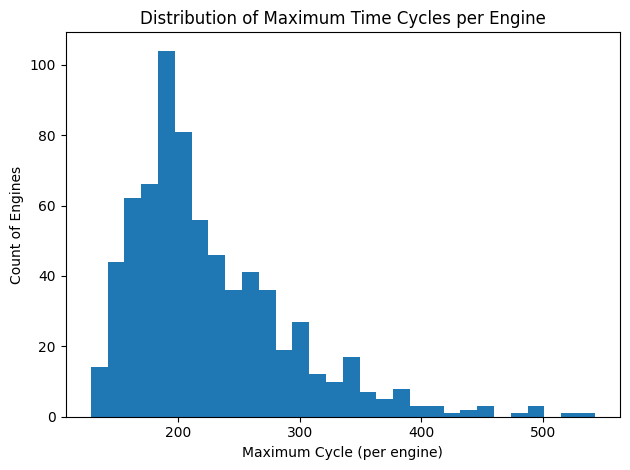

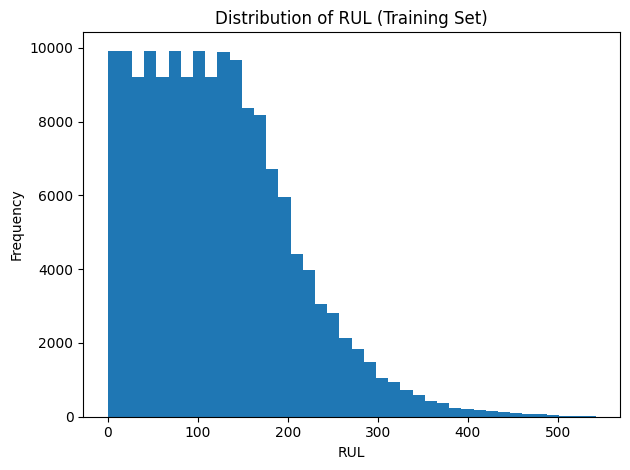

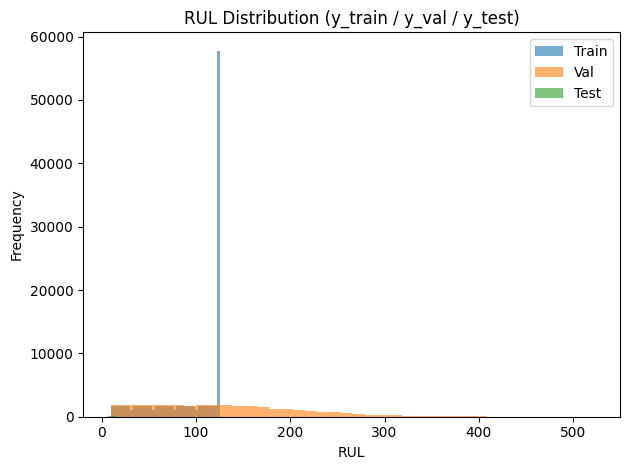

<Figure size 1200x800 with 0 Axes>

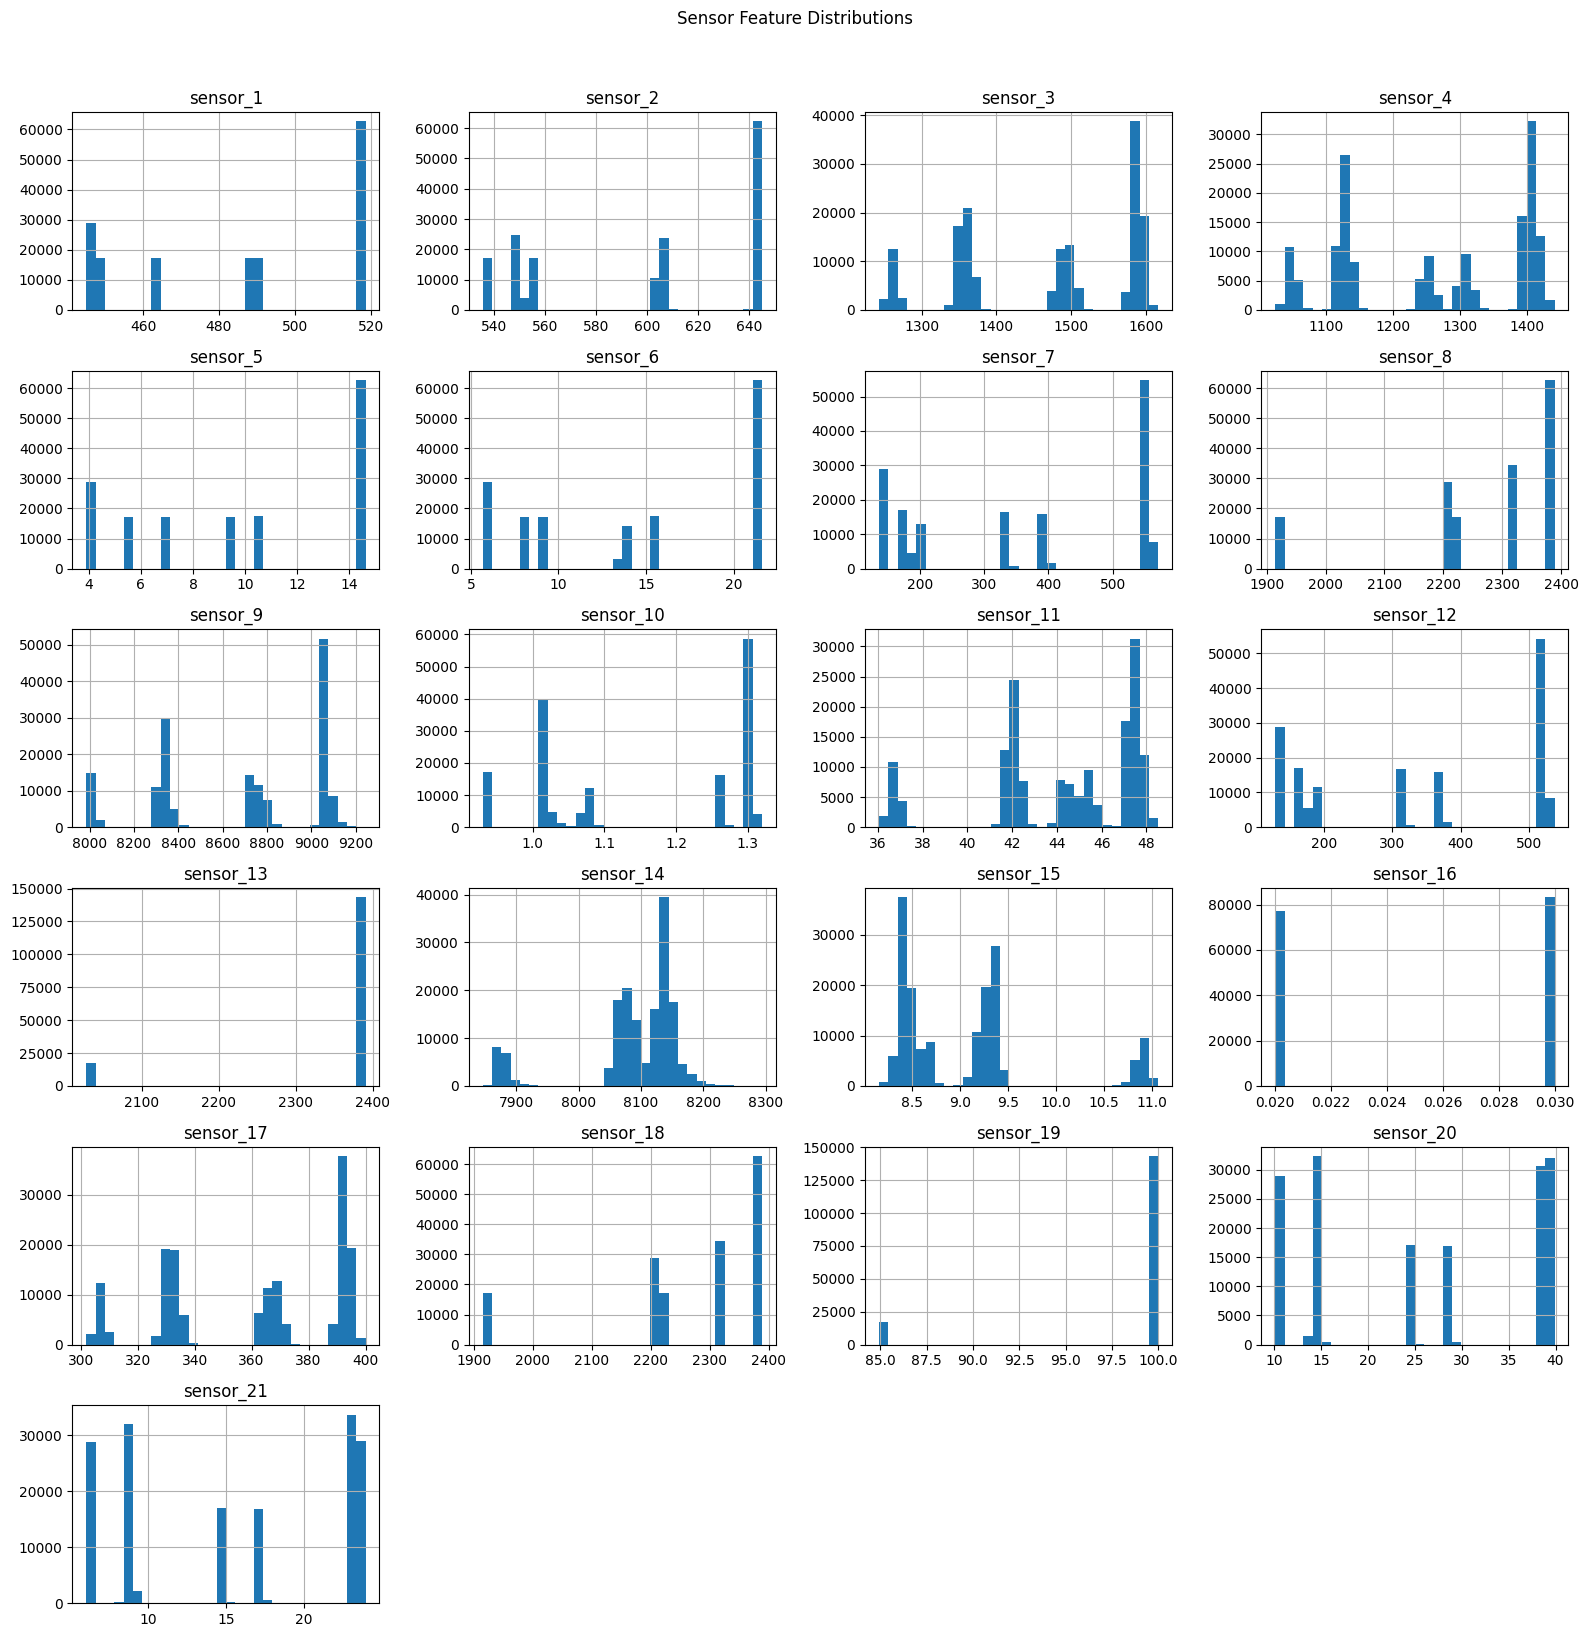

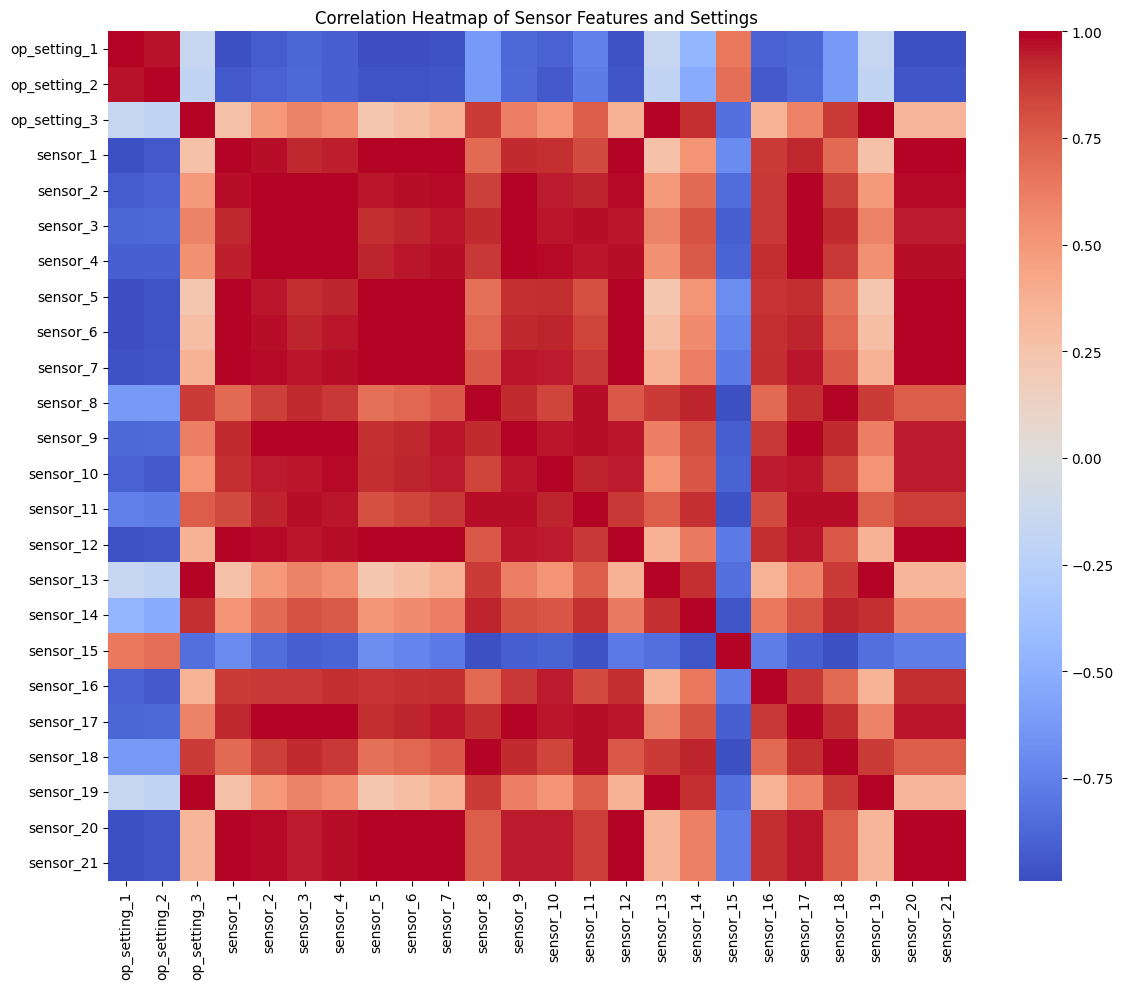

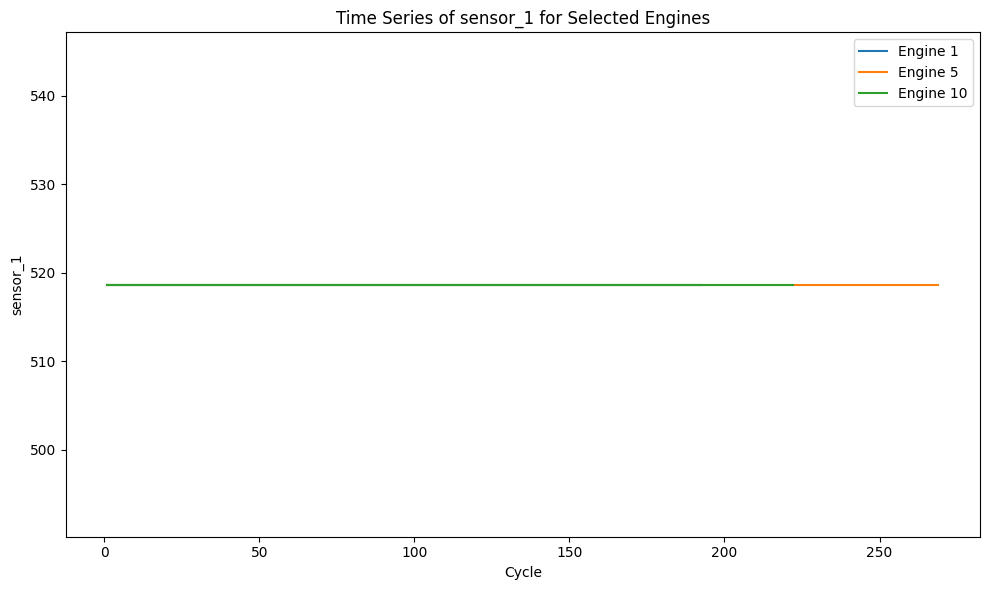

Missing values per column:
 unit_number           0
time_in_cycles        0
op_setting_1          0
op_setting_2          0
op_setting_3          0
sensor_1              0
sensor_2              0
sensor_3              0
sensor_4              0
sensor_5              0
sensor_6              0
sensor_7              0
sensor_8              0
sensor_9              0
sensor_10             0
sensor_11             0
sensor_12             0
sensor_13             0
sensor_14             0
sensor_15             0
sensor_16             0
sensor_17             0
sensor_18             0
sensor_19             0
sensor_20             0
sensor_21             0
global_unit_number    0
RUL                   0
dtype: int64


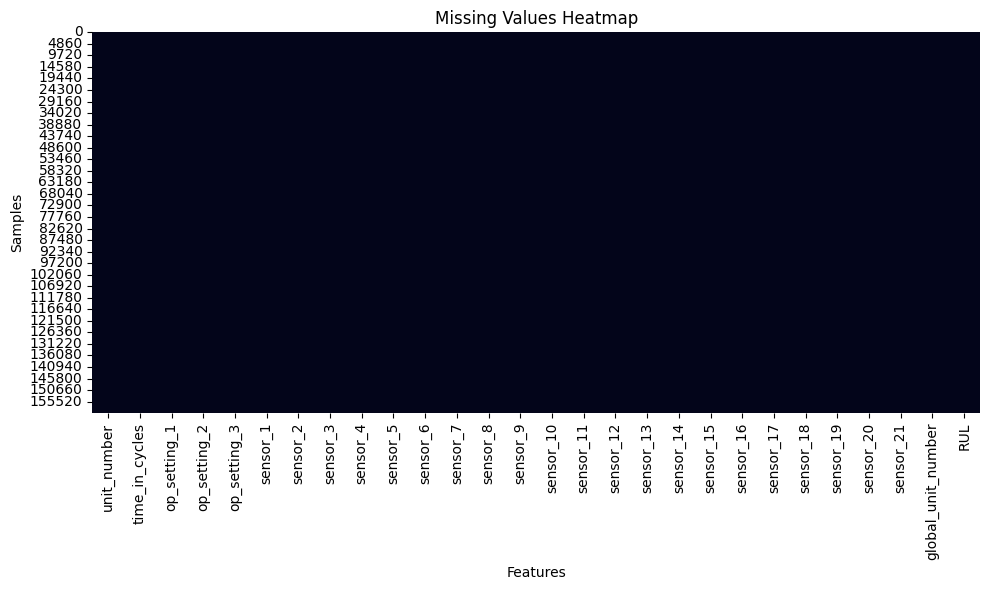

         unit_number  time_in_cycles   op_setting_1   op_setting_2  \
count  160359.000000   160359.000000  160359.000000  160359.000000   
mean      105.553758      123.331338      17.211973       0.410004   
std        72.867325       83.538146      16.527988       0.367938   
min         1.000000        1.000000      -0.008700      -0.000600   
25%        44.000000       57.000000       0.001300       0.000200   
50%        89.000000      114.000000      19.998100       0.620000   
75%       164.000000      173.000000      35.001500       0.840000   
max       260.000000      543.000000      42.008000       0.842000   

        op_setting_3       sensor_1       sensor_2       sensor_3  \
count  160359.000000  160359.000000  160359.000000  160359.000000   
mean       95.724344     485.840890     597.361022    1467.035653   
std        12.359044      30.420388      42.478516     118.175261   
min        60.000000     445.000000     535.480000    1242.670000   
25%       100.000000    

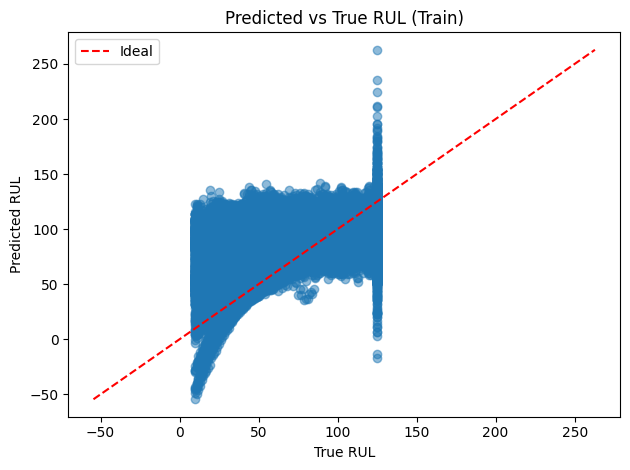

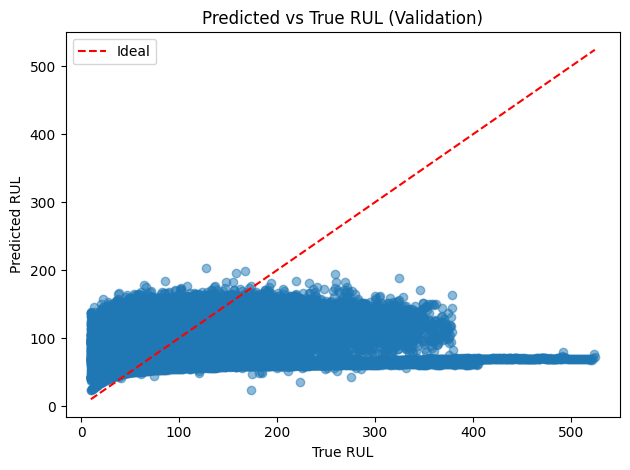

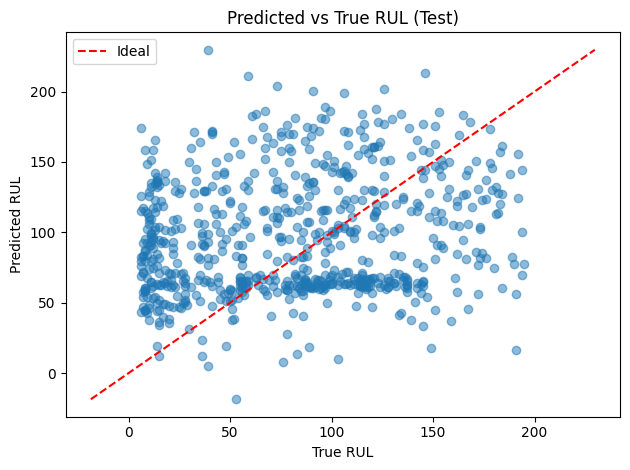

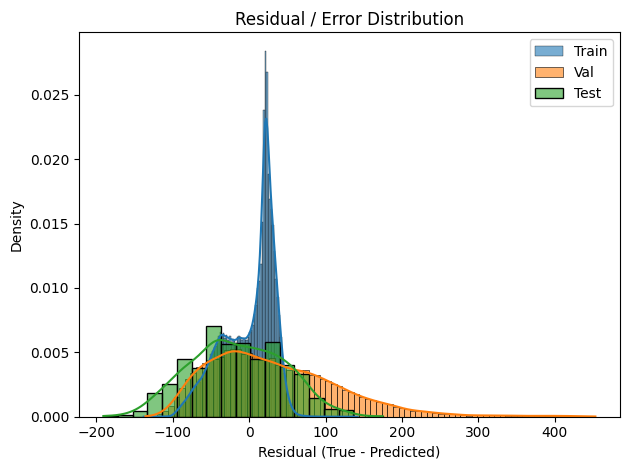

   Split       RMSE        MAE        R2
0  Train  33.724898  28.531672  0.202919
1    Val  92.303793  68.959930 -0.217689
2   Test  62.024559  51.135296 -0.465603


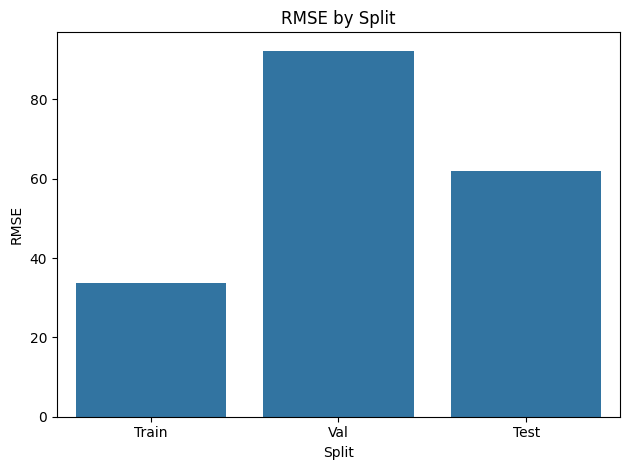

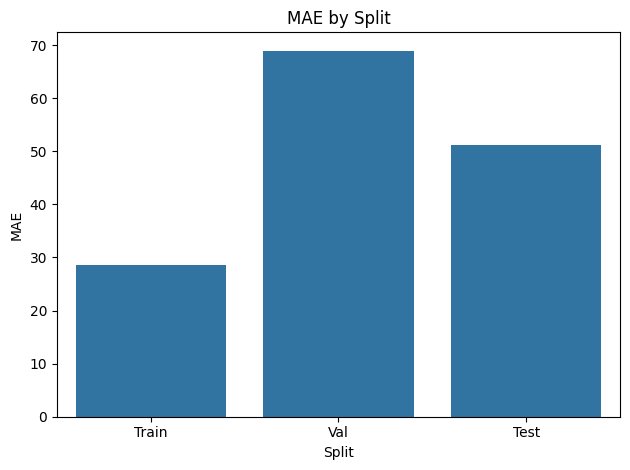

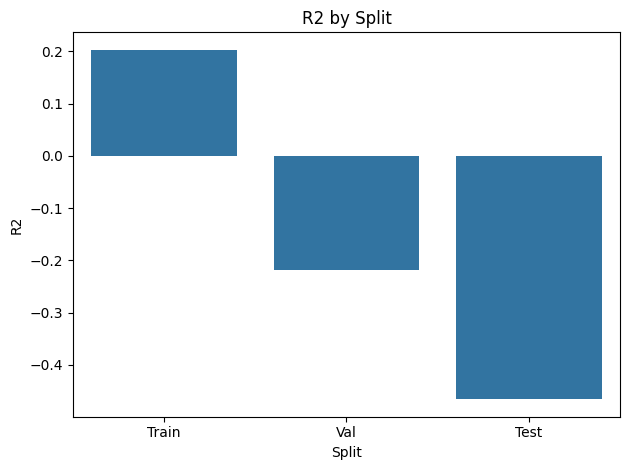

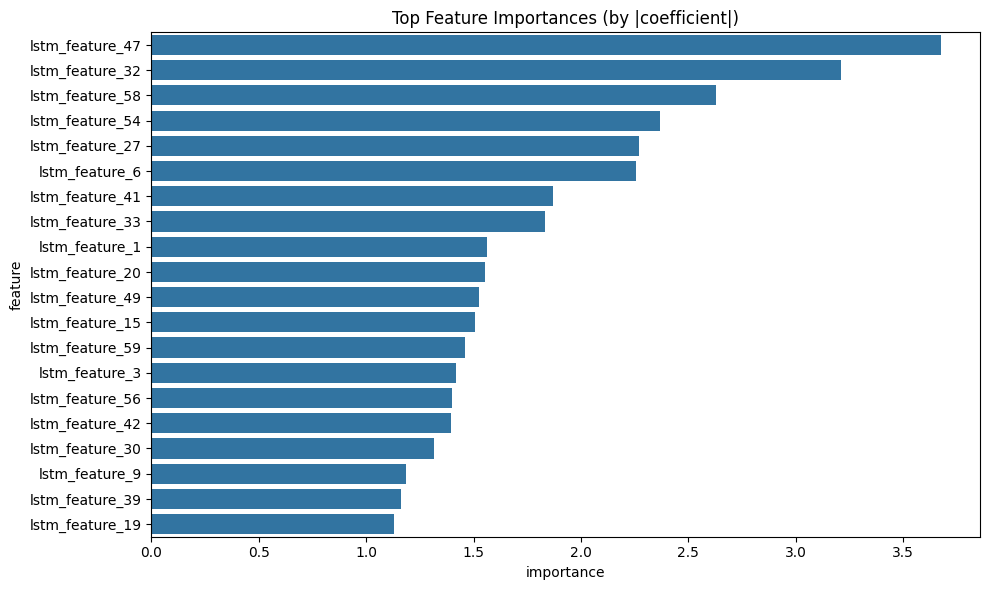

"\nimportances = model_stage4.feature_importances_\nfeat_imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances})\nfeat_imp_df = feat_imp_df.sort_values('importance', ascending=False)\n\nplt.figure(figsize=(10, 6))\nsns.barplot(data=feat_imp_df.head(20), x='importance', y='feature')\nplt.title('Feature Importances (Tree-based Model)')\nplt.tight_layout()\nplt.show()\n"

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# %matplotlib inline  # uncomment in Jupyter if needed

# --------------------------------------------------------
# 1) Distribution of Maximum Time Cycles per Engine
# --------------------------------------------------------
# df_train: CMAPSS training dataframe
# change 'engine_id' and 'cycle' if your names differ
max_cycles = train_df.groupby('global_unit_number')['time_in_cycles'].max()

plt.figure()
plt.hist(max_cycles, bins=30)
plt.xlabel('Maximum Cycle (per engine)')
plt.ylabel('Count of Engines')
plt.title('Distribution of Maximum Time Cycles per Engine')
plt.tight_layout()
plt.show()

# --------------------------------------------------------
# 2) Distribution of RUL (Remaining Useful Life)
# --------------------------------------------------------
# If you have RUL column in df_train:
if 'RUL' in train_df.columns:
    plt.figure()
    plt.hist(train_df['RUL'], bins=40)
    plt.xlabel('RUL')
    plt.ylabel('Frequency')
    plt.title('Distribution of RUL (Training Set)')
    plt.tight_layout()
    plt.show()

# Also from y_* arrays:
plt.figure()
plt.hist(y_train, bins=40, alpha=0.6, label='Train')
plt.hist(y_val,   bins=40, alpha=0.6, label='Val')
plt.hist(y_test,  bins=40, alpha=0.6, label='Test')
plt.xlabel('RUL')
plt.ylabel('Frequency')
plt.title('RUL Distribution (y_train / y_val / y_test)')
plt.legend()
plt.tight_layout()
plt.show()

# --------------------------------------------------------
# 3) Sensor Feature Distributions
# --------------------------------------------------------
sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
plt.figure(figsize=(12, 8))
train_df[sensor_cols].hist(bins=30, layout=(int(np.ceil(len(sensor_cols)/4)), 4), figsize=(16, 16))
plt.suptitle('Sensor Feature Distributions', y=1.02)
plt.tight_layout()
plt.show()

# --------------------------------------------------------
# 4) Correlation Heatmap of Sensor Features and Settings
# --------------------------------------------------------
setting_cols = ['op_setting_1', 'op_setting_2', 'op_setting_3']
corr_cols = setting_cols + sensor_cols  # modify if needed

corr_mat = train_df[corr_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_mat, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Sensor Features and Settings')
plt.tight_layout()
plt.show()

# --------------------------------------------------------
# 5) Time Series Plot of Sensor Values for Selected Engines
# --------------------------------------------------------
selected_engines = [1, 5, 10]  # change engine_ids as needed
sensor_to_plot = sensor_cols[0] if sensor_cols else None

if sensor_to_plot is not None:
    plt.figure(figsize=(10, 6))
    for eng in selected_engines:
        df_e = train_df[train_df['global_unit_number'] == eng]
        plt.plot(df_e['time_in_cycles'], df_e[sensor_to_plot], label=f'Engine {eng}')
    plt.xlabel('Cycle')
    plt.ylabel(sensor_to_plot)
    plt.title(f'Time Series of {sensor_to_plot} for Selected Engines')
    plt.legend()
    plt.tight_layout()
    plt.show()

# --------------------------------------------------------
# 6) Missing Values Heatmap or Summary
# --------------------------------------------------------
# Summary
missing_counts = train_df.isna().sum()
print("Missing values per column:\n", missing_counts)

# Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(train_df.isna(), cbar=False)
plt.title('Missing Values Heatmap')
plt.xlabel('Features')
plt.ylabel('Samples')
plt.tight_layout()
plt.show()

# --------------------------------------------------------
# 7) Statistical Summary Table of Features
# --------------------------------------------------------
stat_summary = train_df.describe()
print(stat_summary)

# --------------------------------------------------------
# 8) Predicted vs. True RUL Scatter Plot
# --------------------------------------------------------
def plot_pred_vs_true(y_true, y_pred, split_name):
    plt.figure()
    plt.scatter(y_true, y_pred, alpha=0.5)
    # Ensure scalar values are used for min() and max()
    min_val = min(y_true.values.min(), y_pred.min())
    max_val = max(y_true.values.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal')
    plt.xlabel('True RUL')
    plt.ylabel('Predicted RUL')
    plt.title(f'Predicted vs True RUL ({split_name})')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_pred_vs_true(y_train, y_pred_train_stage4, 'Train')
plot_pred_vs_true(y_val,   y_pred_val_stage4,   'Validation')
plot_pred_vs_true(y_test,  y_pred_test_stage4,  'Test')

# --------------------------------------------------------
# 9) Residual or Error Distribution Plot
# --------------------------------------------------------
res_train = y_train.values.flatten() - y_pred_train_stage4.flatten()
res_val   = y_val.values.flatten()   - y_pred_val_stage4.flatten()
res_test  = y_test.values.flatten()  - y_pred_test_stage4.flatten()

plt.figure()
sns.histplot(res_train, kde=True, stat='density', label='Train', alpha=0.6)
sns.histplot(res_val,   kde=True, stat='density', label='Val',   alpha=0.6)
sns.histplot(res_test,  kde=True, stat='density', label='Test',  alpha=0.6)
plt.xlabel('Residual (True - Predicted)')
plt.title('Residual / Error Distribution')
plt.legend()
plt.tight_layout()
plt.show()

# --------------------------------------------------------
# 10) Time Series Prediction Visualization
# --------------------------------------------------------
# Example: pick one engine and plot its true vs predicted RUL across cycles
# Assumes you have a dataframe with per-cycle predictions.

# To visualize time series prediction, we need to reconstruct the original `train_df` with predictions.
# This is a bit complex as `y_train` and `y_pred_train_stage4` are already filtered and sequenced.
# A simpler approach for demonstration would be to get the RUL values directly from `train_df`
# and overlay with predictions corresponding to those cycles.

# For simplicity, let's take a sample engine from the training set and plot its actual RUL and predicted RUL.
# Note: This will require more complex mapping if predictions are not 1-to-1 with original cycles.
# Given the current setup, `y_train` corresponds to `y_filtered_clipped` after dropping global_unit_number and skipping first 5 rows.
# We need to map `y_pred_train_stage4` back to the original engine cycles.

# This section would require more detailed reconstruction logic based on how `y_train` was generated.
# For now, let's skip the direct time series prediction plot as it's not straightforward with the current variable state.
# If a detailed plot is required, we would need to align `y_pred_train_stage4` with `train_df`'s cycles.

# --------------------------------------------------------
# 11) Model Performance Metric Bar Chart
# --------------------------------------------------------
def compute_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    return rmse, mae, r2

rmse_train, mae_train, r2_train = compute_metrics(y_train, y_pred_train_stage4)
rmse_val,   mae_val,   r2_val   = compute_metrics(y_val,   y_pred_val_stage4)
rmse_test,  mae_test,  r2_test  = compute_metrics(y_test,  y_pred_test_stage4)

metrics_df = pd.DataFrame({
    'Split': ['Train', 'Val', 'Test'],
    'RMSE':  [rmse_train, rmse_val, rmse_test],
    'MAE':   [mae_train, mae_val, mae_test],
    'R2':    [r2_train,  r2_val,  r2_test]
})
print(metrics_df)

# Example: Bar chart for RMSE, MAE, R2 separately
for metric in ['RMSE', 'MAE', 'R2']:
    plt.figure()
    sns.barplot(data=metrics_df, x='Split', y=metric)
    plt.title(f'{metric} by Split')
    plt.tight_layout()
    plt.show()

# --------------------------------------------------------
# 12) Confusion Matrix (only if you later do classification)
# --------------------------------------------------------
# Example template (commented out):
"""
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true_cls = ...  # class labels
y_pred_cls = ...  # predicted class labels
cm = confusion_matrix(y_true_cls, y_pred_cls)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()
"""

# --------------------------------------------------------
# 13) Feature Importance or Attention Visualization
# --------------------------------------------------------
# (A) If using LinearRegression (model_stage4): use coefficients
#      You must provide the same feature_names order used in training.
try:
    # Assuming 'features' variable holds the names of the features used in model_stage4.coef_
    # model_stage4 is a Ridge model trained on X_train_stage4 which is a concatenation
    # of X_train_lstm_encoded (64 features) and X_train_features (32 features).
    # So, the feature_names need to be adjusted accordingly.
    feature_names = [f'lstm_feature_{i}' for i in range(64)] + [f'ae_feature_{i}' for i in range(32)]
    coefs = model_stage4.coef_.ravel()  # shape (n_features,)
    coef_df = pd.DataFrame({'feature': feature_names, 'importance': np.abs(coefs)})
    coef_df = coef_df.sort_values('importance', ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=coef_df.head(20), x='importance', y='feature')
    plt.title('Top Feature Importances (by |coefficient|)')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("Feature importance plot (linear model) skipped:", e)

# (B) If using tree-based models (RandomForest, XGBoost, etc.):
"""
importances = model_stage4.feature_importances_
feat_imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feat_imp_df = feat_imp_df.sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp_df.head(20), x='importance', y='feature')
plt.title('Feature Importances (Tree-based Model)')
plt.tight_layout()
plt.show()
"""

# (C) If using attention-based model, you’d plot attention weights.
# That is model-architecture specific, so you’ll adapt based on your model.